# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [1]:
# Mackaelan Songco

## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [6]:
g = 9.81 # m/s^2
L = 1.0 # m

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [7]:
def pendulum(t, y):
    theta, omega = y # y[0] = theta, y[1] = omega
    dtheta_dt = omega
    domega_dt = - (g / L) * np.sin(theta)
    return(dtheta_dt, domega_dt) 

Give you equation some initial conditions. Run the cell below.

In [8]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity

Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [9]:
t_span = (0, 10)
t_eval = np.linspace(0, 10, 500)
sol = solve_ivp(pendulum, t_span, [theta_0, omega_0], t_eval = t_eval)

Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [10]:
theta_values = sol.y[0]
time_values = sol.t

Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [11]:
def period(L, g):
    period = 2 * np.pi * np.sqrt(L / g)
    return period

Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [15]:
print(round(period(L, g), 2))

2.01


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [22]:
zero_crossings = np.where(np.diff(np.sign(theta_values)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_values[zero_crossings[1]] - time_values[zero_crossings[0]])
else:
    T_numerical = None

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

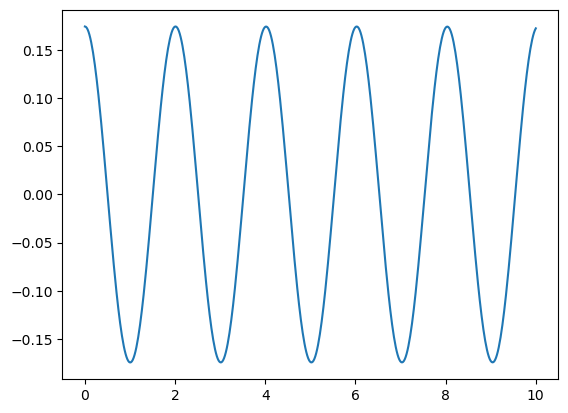

In [23]:
plt.plot(time_values, theta_values, label = "Numerical Solution")

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [25]:
print(round(T_numerical,4))

2.004


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [ ]:
# The approximation was an overestimate but it was still relatively close. 

## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [27]:
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [36]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [46]:
df = pd.read_csv('owid-covid-data.csv')

Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [66]:
df_country = df[(df["location"] == "United States")]
print(df_country)

       iso_code      continent       location        date  total_cases  \
403451      USA  North America  United States  2020-01-05          0.0   
403452      USA  North America  United States  2020-01-06          0.0   
403453      USA  North America  United States  2020-01-07          0.0   
403454      USA  North America  United States  2020-01-08          0.0   
403455      USA  North America  United States  2020-01-09          0.0   
...         ...            ...            ...         ...          ...   
405120      USA  North America  United States  2024-07-31  103436829.0   
405121      USA  North America  United States  2024-08-01  103436829.0   
405122      USA  North America  United States  2024-08-02  103436829.0   
405123      USA  North America  United States  2024-08-03  103436829.0   
405124      USA  North America  United States  2024-08-04  103436829.0   

        new_cases  new_cases_smoothed  total_deaths  new_deaths  \
403451        0.0                 NaN       

From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [71]:
df_country = df_country[['date', 'total_cases']]
df_country['days_since_start'] = (pd.to_datetime(df_country['date']) - pd.to_datetime(df_country['date']).min()).dt.days

Print the first few rows of your `df_country` dataframe.

In [73]:
print(df_country.head(3))

              date  total_cases  days_since_start
403451  2020-01-05          0.0                 0
403452  2020-01-06          0.0                 1
403453  2020-01-07          0.0                 2


In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [74]:
from scipy.optimize import curve_fit

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [101]:
def exponential_growth(t, C_0, r):
    C_T = C_0 * np.exp(r * t)
    return C_T

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [102]:
days = df_country['days_since_start'].head(30)
cases = df_country['total_cases'].head(30)

With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [103]:
popt, pcov = curve_fit(exponential_growth, days, cases, p0=[1, 0.1])
C0_fit, r_fit = popt

Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [104]:
print(round(C0_fit, 2))
print(round(r_fit, 4))

0.12
0.1538


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [112]:
future_days = np.arange(0, 60)

Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [113]:
predicted_cases = exponential_growth(future_days, C0_fit, r_fit)

**Scater** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

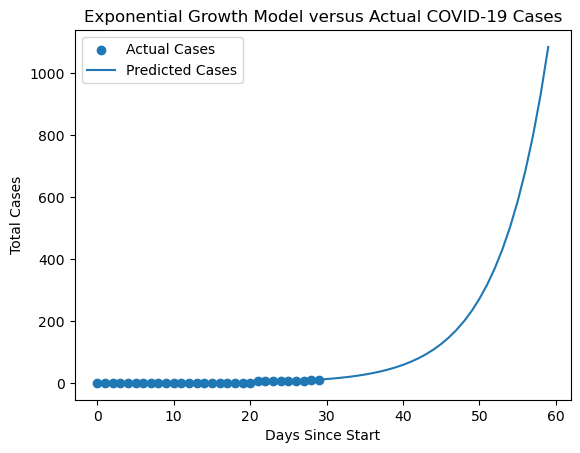

In [117]:
plt.scatter(days, cases, label = 'Actual Cases')
plt.plot(future_days, predicted_cases, label = 'Predicted Cases')
plt.xlabel('Days Since Start')
plt.ylabel('Total Cases')
plt.title('Exponential Growth Model versus Actual COVID-19 Cases')
plt.legend()
plt.show()

How well does your exponential model fit the actual COVID-19 data? 

In [118]:
# While the range from 0 to 30 days matches, given how the "Actual Cases" only goes to 30 days and there is minimal increase, it is uncertain still.

Make another plot but this time to **90 days**.

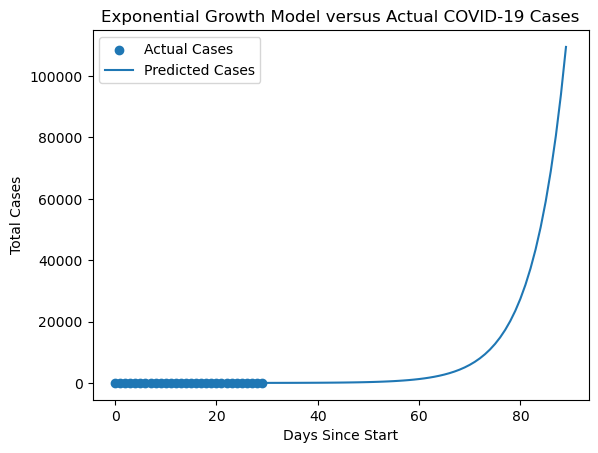

In [122]:
future_days = np.arange(0, 90)
predicted_cases = exponential_growth(future_days, C0_fit, r_fit)
plt.scatter(days, cases, label = 'Actual Cases')
plt.plot(future_days, predicted_cases, label = 'Predicted Cases')
plt.xlabel('Days Since Start')
plt.ylabel('Total Cases')
plt.title('Exponential Growth Model versus Actual COVID-19 Cases')
plt.legend()
plt.show()

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [128]:
print(predicted_cases[87])

80497.11186068892


## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

In [237]:
import seaborn as sns
df = sns.load_dataset("attention")
# I am under the assumption that "subject" refers to their ages. 

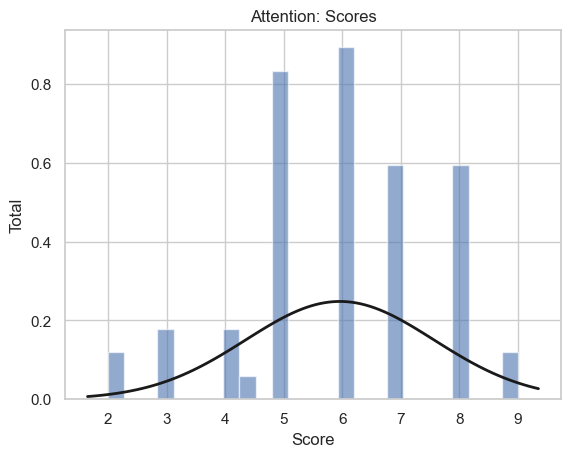

In [261]:
from scipy.stats import norm

scores = df['score']
mu, std = norm.fit(scores)
plt.hist(scores, density=True, alpha=0.6, color='b')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'k', linewidth = 2)
title = "Attention: Scores"
plt.title(title)
plt.xlabel('Score')
plt.ylabel('Total')
plt.show()

On it's own branch, submit this notebook to Gradescope! 

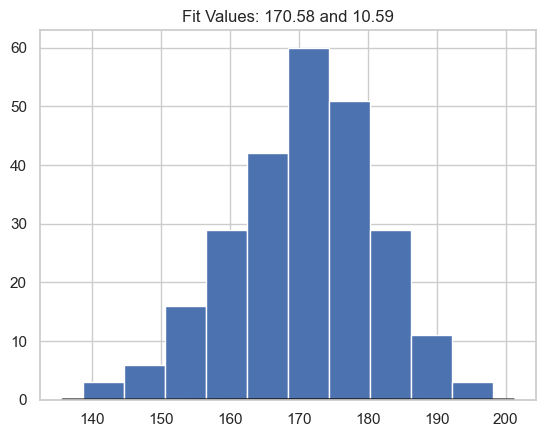

In [259]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Generate some data for this 
# demonstration.
data = np.random.normal(170, 10, 250)

# Fit a normal distribution to
# the data:
# mean and standard deviation
mu, std = norm.fit(data) 

# Plot the histogram.
plt.hist(data, bins=25, density=True, alpha=0.6, color='b')

# Plot the PDF.
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'k', linewidth=2)
title = "Fit Values: {:.2f} and {:.2f}".format(mu, std)
plt.title(title)

plt.show()